# SIT720 8.1D: Sydney Housing Price Prediction and Decision Support System

Hassan Riaz | Student ID 226433107

Deakin University, SIT720 Machine Learning, Trimester 2 2026

All data in this notebook was collected from real sold-property listings. Nothing is simulated.

## Setup

Imports, display settings and shared constants used throughout the notebook.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (make_scorer, mean_absolute_error,
                             mean_squared_error, r2_score)
from sklearn.model_selection import (KFold, cross_validate, learning_curve,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd() if (Path.cwd() / 'schema.py').exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import features
import schema

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = schema.RANDOM_STATE
np.random.seed(RANDOM_STATE)
pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)
print('Setup complete.')

Setup complete.


# Part 1: Problem Definition and Data Collection

A real estate agency needs an indicative sale price before a formal appraisal. The task is to predict the sale price of a Sydney residential property from its observable characteristics.
Three suburbs were selected so that the models are tested across genuinely different markets rather than three samples of one market.

In [2]:
suburb_table = pd.DataFrame([
    {
        'suburb': suburb,
        'postcode': meta['postcode'],
        'region': meta['region'],
        'distance_to_cbd_km': meta['distance_to_cbd_km'],
        'profile': meta['profile'],
    }
    for suburb, meta in schema.SUBURBS.items()
])
print('=== Selected suburbs ===')
print(suburb_table.to_string(index=False))
print()
print('Brief requirements: at least', schema.MIN_TOTAL_RECORDS,
      'records, minimum', schema.MIN_PER_SUBURB, 'per suburb')

=== Selected suburbs ===
      suburb  postcode            region  distance_to_cbd_km                                                                                                                   profile
      Mosman      2088 Lower North Shore                 8.0                                          Premium harbourside market dominated by detached houses on small-to-medium lots.
  Parramatta      2150    Western Sydney                24.0 Sydney's second CBD, high-density apartment market with strong rail and light-rail access and a large diverse population.
Campbelltown      2560 South-West Sydney                50.0                   Affordable outer-metropolitan market of detached family homes with a young and fast-growing population.

Brief requirements: at least 100 records, minimum 30 per suburb


## 1.1 Load the collected dataset

Data was collected from real sold properties on domain.com.au. The method, the inclusion rules and the exclusions are documented in docs/collection_notes.md.

In [3]:
df = features.load_dataset()

print('=== Loaded dataset ===')
print('Shape:', df.shape)
print()
print(df.head(5).to_string(index=False))

=== Loaded dataset ===
Shape: (105, 19)

property_id suburb  postcode              address  sale_price  sale_date   sale_method property_type  bedrooms  bathrooms  car_spaces  total_rooms  distance_to_cbd_km  condition_rating  has_pool  has_water_view                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [4]:
counts = df['suburb'].value_counts().reindex(list(schema.SUBURBS))

print('=== Records per suburb ===')
for suburb, n in counts.items():
    status = 'OK' if n >= schema.MIN_PER_SUBURB else 'BELOW MINIMUM'
    print(f'  {suburb:<14} {n:>4}   [{status}]')
print(f'  {"TOTAL":<14} {len(df):>4}   [minimum {schema.MIN_TOTAL_RECORDS}]')
print()

assert len(df) >= schema.MIN_TOTAL_RECORDS, 'dataset below the required 100 records'
assert (counts >= schema.MIN_PER_SUBURB).all(), 'a suburb has fewer than 30 records'
print('Brief requirements satisfied.')

=== Records per suburb ===
  Mosman           35   [OK]
  Parramatta       35   [OK]
  Campbelltown     35   [OK]
  TOTAL           105   [minimum 100]

Brief requirements satisfied.


## 1.2 Dataset quality

Missingness, duplicates and value ranges. The problems found here are discussed in section 1.5.

In [5]:
missing = pd.DataFrame({
    'missing': df.isna().sum(),
    'pct': (df.isna().mean() * 100).round(1),
})
missing = missing[missing['missing'] > 0].sort_values('missing', ascending=False)

print('=== Missing values by column ===')
print(missing.to_string() if len(missing) else 'No missing values in any column.')
print()
print('Columns with no missing values:', int((df.isna().sum() == 0).sum()),
      'of', df.shape[1])

=== Missing values by column ===
                   missing    pct
condition_rating       105  100.0
car_spaces              12   11.4
agent_description        1    1.0

Columns with no missing values: 16 of 19


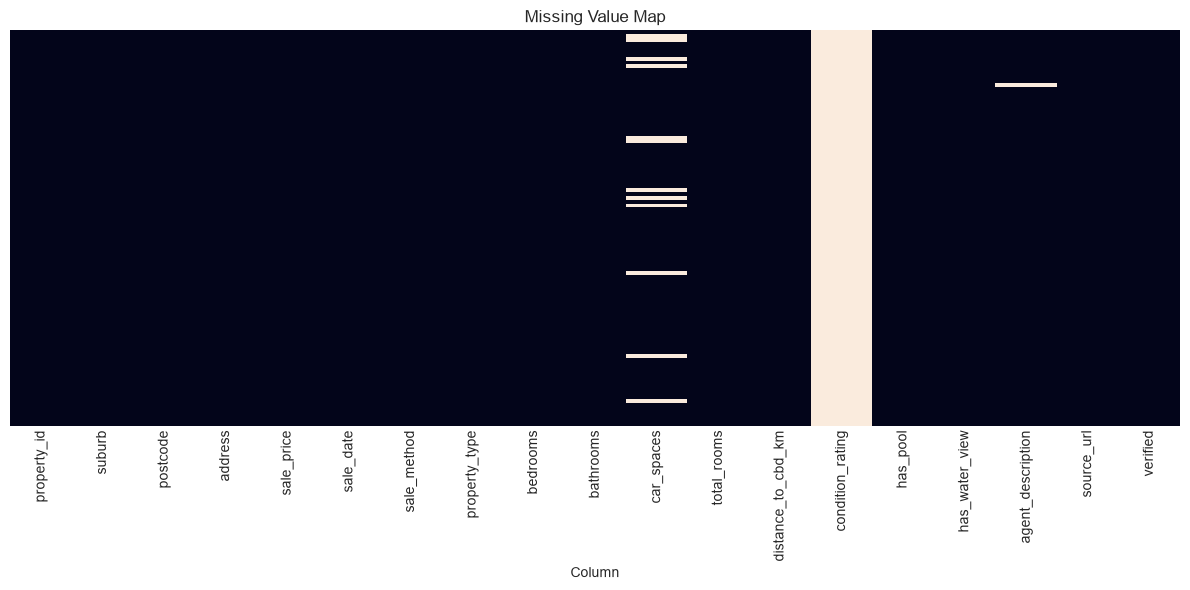

In [6]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False, cmap='rocket', yticklabels=False)
plt.title('Missing Value Map')
plt.xlabel('Column')
plt.tight_layout()
plt.show()

In [7]:
required = df[schema.REQUIRED_COLUMNS]
incomplete = required[required.isna().any(axis=1)]

print('=== Completeness of required fields ===')
print('Rows missing at least one required value:', len(incomplete))
print()
print('Duplicate source URLs:', int((df['source_url'].duplicated(keep=False)).sum()))
print('Duplicate property IDs:', int(df['property_id'].duplicated().sum()))
print('Duplicate address within suburb:',
      int(df.duplicated(subset=['suburb', 'address']).sum()))
print()
print('Distinct sale methods recorded:')
print(df['sale_method'].value_counts().to_string())

=== Completeness of required fields ===
Rows missing at least one required value: 0

Duplicate source URLs: 0
Duplicate property IDs: 0
Duplicate address within suburb: 0

Distinct sale methods recorded:
sale_method
privateTreaty    105


In [8]:
desc_words = df['agent_description'].fillna('').astype(str).str.split().str.len()

quality = pd.DataFrame({
    'metric': [
        'records', 'suburbs', 'sale window',
        'agent descriptions present', 'mean description words',
        'median sale price', 'lowest sale price', 'highest sale price',
        'distinct property types', 'distinct sale methods',
    ],
    'value': [
        len(df), df['suburb'].nunique(),
        f"{df['sale_date'].min():%Y-%m-%d} to {df['sale_date'].max():%Y-%m-%d}",
        f"{int(desc_words.gt(40).sum())} of {len(df)}",
        f"{desc_words.mean():.0f}",
        f"${df['sale_price'].median():,.0f}",
        f"${df['sale_price'].min():,.0f}",
        f"${df['sale_price'].max():,.0f}",
        df['property_type'].nunique(), df['sale_method'].nunique(),
    ],
})
print('=== Dataset quality summary ===')
print(quality.to_string(index=False))

=== Dataset quality summary ===
                    metric                    value
                   records                      105
                   suburbs                        3
               sale window 2026-05-22 to 2026-09-12
agent descriptions present               104 of 105
    mean description words                      283
         median sale price                 $700,000
         lowest sale price                 $320,000
        highest sale price              $11,650,000
   distinct property types                        5
     distinct sale methods                        1


## 1.3 Price context by suburb

A first look at how the three markets differ, before any modelling.

In [9]:
summary = df.groupby('suburb')['sale_price'].describe()[['count', 'mean', '50%', 'min', 'max']]
summary.columns = ['count', 'mean', 'median', 'min', 'max']
summary = summary.reindex(list(schema.SUBURBS))

print('=== Sale price by suburb ===')
print(summary.round(0).to_string())
print()
print('Ratio of highest to lowest suburb median: '
      f"{summary['median'].max() / summary['median'].min():.1f}x")
print()
print('=== Dwelling type mix ===')
mix = pd.crosstab(df['suburb'], df['property_type']).reindex(list(schema.SUBURBS)).fillna(0).astype(int)
print(mix.to_string())

=== Sale price by suburb ===
              count       mean     median       min         max
suburb                                                         
Mosman         35.0  2537043.0  1310000.0  700000.0  11650000.0
Parramatta     35.0   584200.0   590000.0  320000.0    800000.0
Campbelltown   35.0   723561.0   637595.0  363000.0   1185000.0

Ratio of highest to lowest suburb median: 2.2x

=== Dwelling type mix ===
property_type  Apartment  House  SemiDetached  Terrace  Townhouse
suburb                                                           
Mosman                25      5             2        0          3
Parramatta            34      0             0        0          1
Campbelltown          19     12             2        1          1


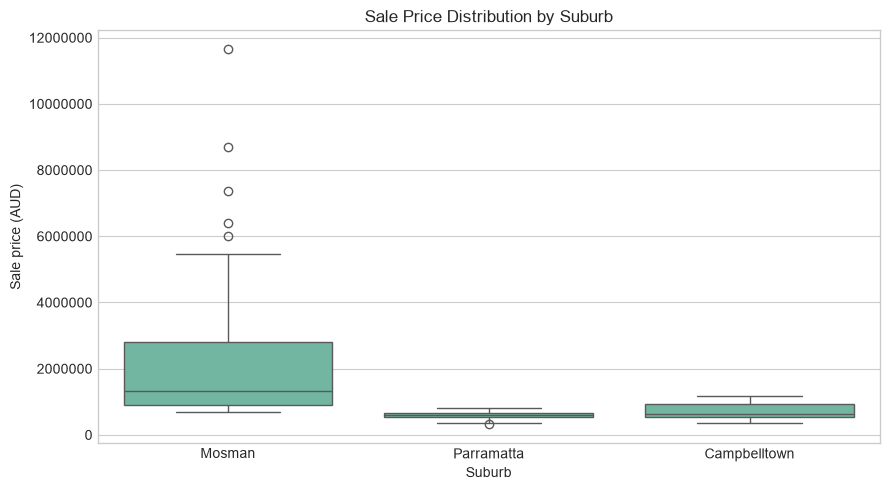

In [10]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='suburb', y='sale_price', order=list(schema.SUBURBS))
plt.title('Sale Price Distribution by Suburb')
plt.xlabel('Suburb')
plt.ylabel('Sale price (AUD)')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [11]:
df['price_per_room'] = df['sale_price'] / df['total_rooms'].replace(0, np.nan)
pps = df.groupby('suburb')['price_per_room'].median().reindex(list(schema.SUBURBS))

print('=== Median price per room (size-normalised) ===')
print(pps.round(0).to_string())
print()
print('Raw price differences partly reflect dwelling size. Price per room')
print('separates the location premium from the size effect. Because land size and')
print('floor area are not published on sold listings, rooms is the size proxy')
print('available and this is a documented limitation of the dataset.')

=== Median price per room (size-normalised) ===
suburb
Mosman          432500.0
Parramatta      173750.0
Campbelltown    169286.0

Raw price differences partly reflect dwelling size. Price per room
separates the location premium from the size effect. Because land size and
floor area are not published on sold listings, rooms is the size proxy
available and this is a documented limitation of the dataset.


## 1.4 The three variables expected to matter most

Stated before any feature is created, so the expectation is recorded honestly rather than rationalised afterwards.

The three variables expected to have the strongest influence are **property type**, **distance to the CBD**, and **dwelling size as proxied by the number of rooms**.

Property type should matter most because it separates the two fundamentally different price-generating processes in this data. Apartments are priced on internal floor area and building amenity, whereas houses are priced largely on land, which the dataset cannot observe. Distance to the CBD should capture the location premium that separates Mosman from Campbelltown. Room count should capture dwelling size, which is likely to be the only usable size signal for apartments.

In [12]:
candidates = [c for c in ['bedrooms', 'bathrooms', 'total_rooms', 'car_spaces',
                          'distance_to_cbd_km', 'has_pool', 'has_water_view']
              if c in df.columns]

corr_with_price = (df[candidates + ['sale_price']]
                   .corr(numeric_only=True)['sale_price']
                   .drop('sale_price')
                   .sort_values(key=abs, ascending=False))

print('=== Correlation of candidate predictors with sale price ===')
print(corr_with_price.round(3).to_string())
print()
print('Correlation is linear and ignores the property-type split, so it can only')
print('be a first indication. It is examined by type below.')

=== Correlation of candidate predictors with sale price ===
bathrooms             0.699
total_rooms           0.666
car_spaces            0.581
bedrooms              0.559
has_pool              0.418
distance_to_cbd_km   -0.380
has_water_view        0.121

Correlation is linear and ignores the property-type split, so it can only
be a first indication. It is examined by type below.


In [13]:
type_effect = df.groupby('property_type')['sale_price'].agg(['count', 'median']).round(0)
type_effect = type_effect[type_effect['count'] >= 3].sort_values('median', ascending=False)

print('=== Price by property type ===')
print(type_effect.to_string())
print()
print('=== Correlation with price, split by dwelling class ===')
for label, subset in (('Houses and terraces',
                       df[df['property_type'].isin(['House', 'Terrace', 'SemiDetached'])]),
                      ('Apartments and townhouses',
                       df[df['property_type'].isin(['Apartment', 'Townhouse'])])):
    if len(subset) > 5:
        print(f'  {label} (n={len(subset)}):')
        sub_corr = subset[['bedrooms', 'bathrooms', 'total_rooms', 'distance_to_cbd_km',
                           'sale_price']].corr(numeric_only=True)['sale_price'].drop('sale_price')
        print('   ', sub_corr.round(3).to_dict())

=== Price by property type ===
               count     median
property_type                  
Townhouse          5  2180000.0
SemiDetached       4  1965000.0
House             17   980000.0
Apartment         78   650000.0

=== Correlation with price, split by dwelling class ===
  Houses and terraces (n=22):
    {'bedrooms': 0.355, 'bathrooms': 0.775, 'total_rooms': 0.642, 'distance_to_cbd_km': -0.85}
  Apartments and townhouses (n=83):
    {'bedrooms': 0.587, 'bathrooms': 0.439, 'total_rooms': 0.577, 'distance_to_cbd_km': -0.429}


## 1.5 Data collection challenges, bias and limitations

Collection was browser-assisted from domain.com.au sold listings, then verified row by row. Several problems are visible in the data itself.

**Prices are frequently withheld.** Of every listing read, only about one in ten disclosed a price. Those properties are absent from the dataset, so the sample is not a random draw of suburb sales. If disclosure correlates with price band or dwelling type, the models inherit that bias.

**Land size and floor area are unavailable.** Domain does not publish them for sold listings. This is the most consequential gap, because land size would plausibly have been the strongest single predictor for houses. Room count is a weaker substitute and cannot separate a small house on a large lot from a large house on a small one.

**Marketing text is not neutral.** Agent descriptions emphasise positives, so the text features measure advertised desirability rather than objective quality.

**Sale prices were excluded when ranged.** A vendor guide is not a realised sale result, so ranged prices were dropped rather than approximated.

In [14]:
excluded_path = schema.DATA_DIR / 'excluded_listings.csv'
if excluded_path.exists():
    excluded = pd.read_csv(excluded_path)
    print('=== Listings read but excluded, with reasons ===')
    print(f'Total excluded: {len(excluded)}')
    print()
    print(excluded['reason'].value_counts().to_string())
    print()
    withheld = excluded['reason'].str.contains('withheld', na=False).sum()
    print(f'{withheld} of {len(excluded)} exclusions were withheld prices,')
    print(f'which is {100 * withheld / len(excluded):.0f}% of all exclusions.')
    print('This is direct evidence of the selection bias described above.')
else:
    print('excluded_listings.csv not found.')

=== Listings read but excluded, with reasons ===
Total excluded: 116

reason
price withheld or not a single figure    82
tag is not a completed sale              27
missing bedrooms or bathrooms             5
retirement property                       2

82 of 116 exclusions were withheld prices,
which is 71% of all exclusions.
This is direct evidence of the selection bias described above.


In [15]:
missing_by_type = df.assign(
    no_description=df['agent_description'].fillna('').str.strip().eq(''),
).groupby('property_type')[['no_description']].mean().round(2)

print('=== Share of records with no agent description, by property type ===')
print(missing_by_type.to_string())
print()
print('Any type with a high share has its text features effectively switched off,')
print('so those rows are modelled on structural variables alone.')

=== Share of records with no agent description, by property type ===
               no_description
property_type                
Apartment                0.00
House                    0.06
SemiDetached             0.00
Terrace                  0.00
Townhouse                0.00

Any type with a high share has its text features effectively switched off,
so those rows are modelled on structural variables alone.


# Part 2: Data Understanding and Feature Engineering

This part explores the price distribution, differences between suburbs, and unusual observations, then creates engineered features after the expectations above were recorded.

## 2.1 Price distribution

In [16]:
price = df['sale_price']

print('=== Target distribution ===')
print(price.describe().round(0).to_string())
print()
print(f'Skewness:  {price.skew():.2f}')
print(f'Kurtosis:  {price.kurtosis():.2f}')
print(f'Coefficient of variation: {price.std() / price.mean():.3f}')
print(f'Log-price skewness: {np.log(price).skew():.2f}')

=== Target distribution ===
count         105.0
mean      1281601.0
std       1748835.0
min        320000.0
25%        570000.0
50%        700000.0
75%       1030000.0
max      11650000.0

Skewness:  3.80
Kurtosis:  16.01
Coefficient of variation: 1.365
Log-price skewness: 1.75


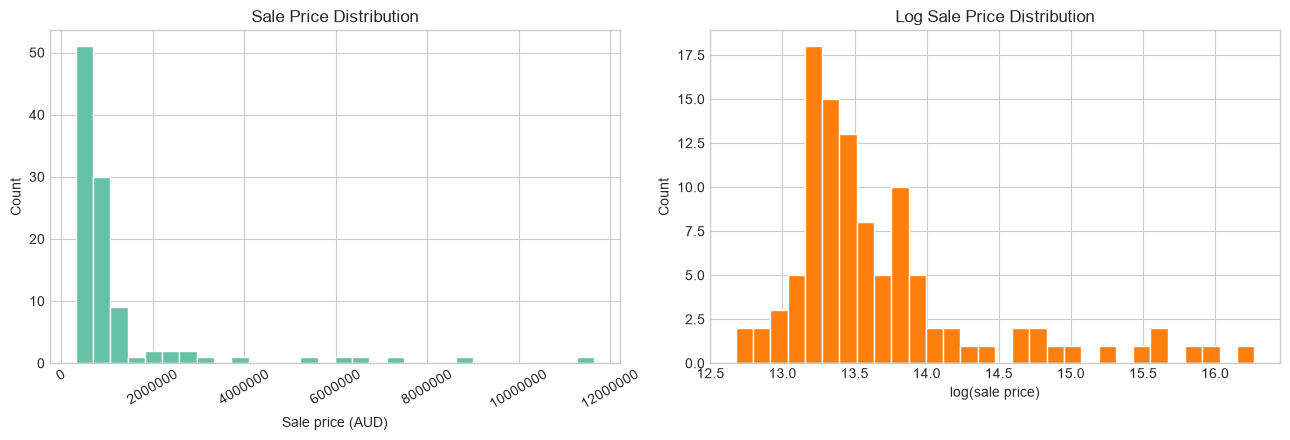

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(price, bins=30, edgecolor='white')
axes[0].set_title('Sale Price Distribution')
axes[0].set_xlabel('Sale price (AUD)')
axes[0].set_ylabel('Count')
axes[0].ticklabel_format(style='plain', axis='x')
axes[0].tick_params(axis='x', rotation=30)

axes[1].hist(np.log(price), bins=30, edgecolor='white', color='tab:orange')
axes[1].set_title('Log Sale Price Distribution')
axes[1].set_xlabel('log(sale price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [18]:
by_suburb = df.groupby('suburb')['sale_price'].describe()[['count', '50%', 'std']]
by_suburb.columns = ['count', 'median', 'std']
by_suburb = by_suburb.reindex(list(schema.SUBURBS))

print('=== Dispersion by suburb ===')
print(by_suburb.round(0).to_string())
print()
ratio = float(by_suburb['std'].max() / by_suburb['std'].min())
print(f'Highest suburb standard deviation is {ratio:.1f}x the lowest.')
print('RMSE in dollars is therefore dominated by the widest-spread suburb,')
print('which is why MAE and MAPE are reported alongside it throughout Part 3.')

=== Dispersion by suburb ===
              count     median        std
suburb                                   
Mosman         35.0  1310000.0  2616613.0
Parramatta     35.0   590000.0   105385.0
Campbelltown   35.0   637595.0   231683.0

Highest suburb standard deviation is 24.8x the lowest.
RMSE in dollars is therefore dominated by the widest-spread suburb,
which is why MAE and MAPE are reported alongside it throughout Part 3.


## 2.2 Differences between suburbs

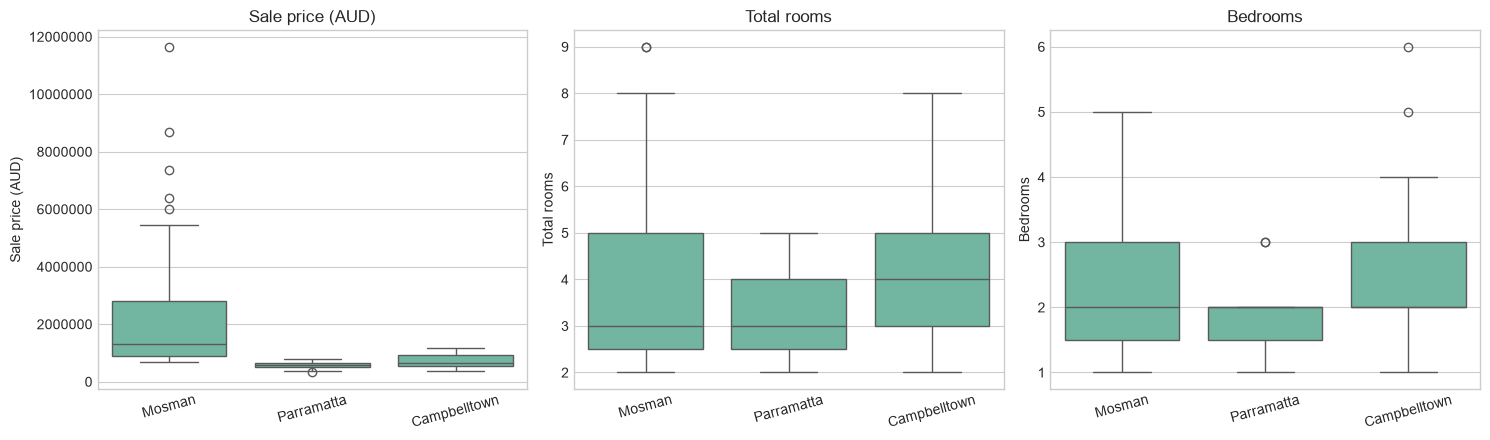

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, metric, label in zip(
    axes,
    ['sale_price', 'total_rooms', 'bedrooms'],
    ['Sale price (AUD)', 'Total rooms', 'Bedrooms'],
):
    sns.boxplot(data=df, x='suburb', y=metric, order=list(schema.SUBURBS), ax=ax)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=15)

axes[0].ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [20]:
type_mix = pd.crosstab(df['suburb'], df['property_type']).reindex(list(schema.SUBURBS)).fillna(0).astype(int)
shares = (type_mix.div(type_mix.sum(axis=1), axis=0) * 100).round(0)

print('=== Property type mix by suburb (count) ===')
print(type_mix.to_string())
print()
print('=== Same mix as a share of each suburb (%) ===')
print(shares.to_string())
print()
print('The suburbs are not three samples of one market. Parramatta is almost')
print('entirely apartments, while the other two are mixed, which is the contrast')
print('the modelling has to handle.')

=== Property type mix by suburb (count) ===
property_type  Apartment  House  SemiDetached  Terrace  Townhouse
suburb                                                           
Mosman                25      5             2        0          3
Parramatta            34      0             0        0          1
Campbelltown          19     12             2        1          1

=== Same mix as a share of each suburb (%) ===
property_type  Apartment  House  SemiDetached  Terrace  Townhouse
suburb                                                           
Mosman              71.0   14.0           6.0      0.0        9.0
Parramatta          97.0    0.0           0.0      0.0        3.0
Campbelltown        54.0   34.0           6.0      3.0        3.0

The suburbs are not three samples of one market. Parramatta is almost
entirely apartments, while the other two are mixed, which is the contrast
the modelling has to handle.


## 2.3 Trends over time

Sales span several months. If the market moved over that window, the sale date carries signal.

In [21]:
df['sale_month'] = df['sale_date'].dt.to_period('M').astype(str)
monthly = df.groupby('sale_month')['sale_price'].agg(['count', 'median']).round(0)

print('=== Median price by month ===')
print(monthly.to_string())
print()
corr_time = df['sale_date'].astype('int64').corr(df['sale_price'])
print(f'Correlation between sale date and price: {corr_time:.3f}')
print()
print('Number of distinct months covered:', df['sale_month'].nunique())

=== Median price by month ===
            count     median
sale_month                  
2026-05         6  1210000.0
2026-06        15  1925000.0
2026-07        23   865000.0
2026-08        47   637595.0
2026-09        14   575000.0

Correlation between sale date and price: -0.428

Number of distinct months covered: 5


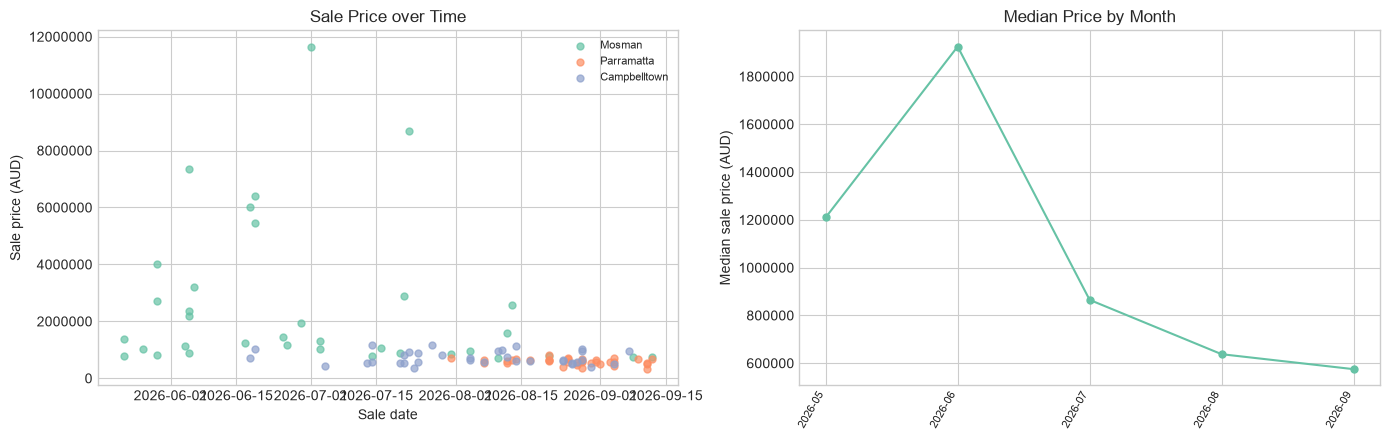

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for suburb in schema.SUBURBS:
    sub = df[df['suburb'] == suburb]
    axes[0].scatter(sub['sale_date'], sub['sale_price'], label=suburb, alpha=0.7, s=25)
axes[0].set_title('Sale Price over Time')
axes[0].set_xlabel('Sale date')
axes[0].set_ylabel('Sale price (AUD)')
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].legend(fontsize=8)

order = monthly.index.tolist()
axes[1].plot(range(len(order)), monthly['median'].values, marker='o', markersize=5)
axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels(order, rotation=60, ha='right', fontsize=8)
axes[1].set_title('Median Price by Month')
axes[1].set_ylabel('Median sale price (AUD)')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

## 2.4 Outliers and unusual observations

In [23]:
q1, q3 = df['sale_price'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df['price_outlier_iqr'] = (df['sale_price'] < lower) | (df['sale_price'] > upper)
df['price_z'] = (df['sale_price'] - df['sale_price'].mean()) / df['sale_price'].std()
df['price_outlier_z'] = df['price_z'].abs() > 3

print('=== Outlier detection on sale price ===')
print(f'IQR fence: ${lower:,.0f} to ${upper:,.0f}')
print(f'Flagged by IQR rule: {int(df["price_outlier_iqr"].sum())}')
print(f'Flagged by |z| > 3:  {int(df["price_outlier_z"].sum())}')
print()
cols = ['property_id', 'suburb', 'property_type', 'bedrooms', 'total_rooms', 'sale_price']
print(df.loc[df['price_outlier_iqr'], cols]
      .sort_values('sale_price', ascending=False).to_string(index=False))

=== Outlier detection on sale price ===
IQR fence: $-120,000 to $1,720,000
Flagged by IQR rule: 14
Flagged by |z| > 3:  3

property_id suburb property_type  bedrooms  total_rooms  sale_price
    MOS-016 Mosman         House         4            8  11650000.0
    MOS-007 Mosman         House         4            7   8700000.0
    MOS-022 Mosman         House         5            9   7360000.0
    MOS-017 Mosman         House         5            9   6399000.0
    MOS-026 Mosman     Apartment         4            7   6000000.0
    MOS-015 Mosman         House         5            8   5450000.0
    MOS-035 Mosman     Apartment         3            5   4000000.0
    MOS-027 Mosman  SemiDetached         4            6   3200000.0
    MOS-009 Mosman  SemiDetached         3            5   2900000.0
    MOS-031 Mosman     Townhouse         3            5   2725000.0
    MOS-006 Mosman     Apartment         3            5   2558000.0
    MOS-023 Mosman     Townhouse         3            5   238

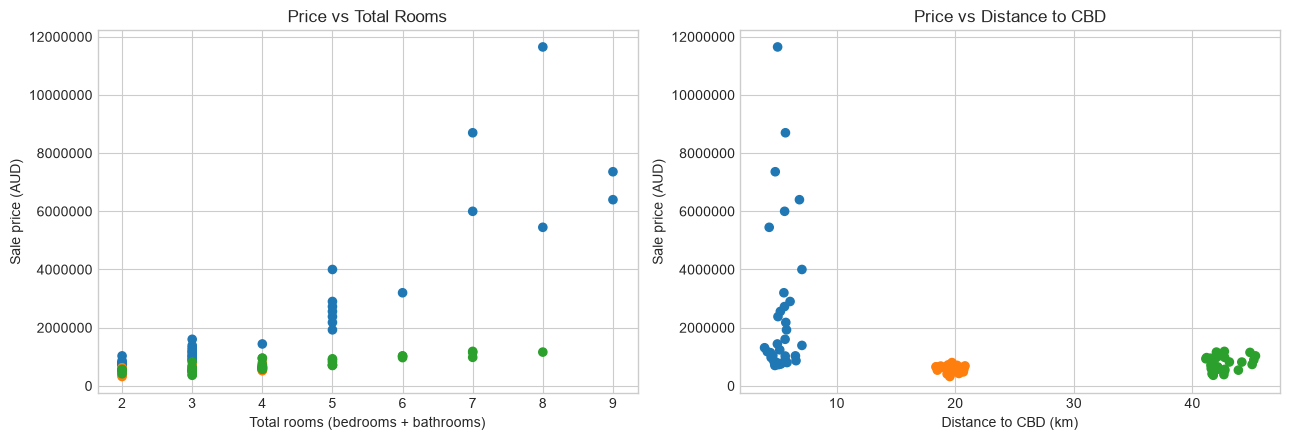

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = df['suburb'].map({s: c for s, c in zip(schema.SUBURBS,
                                                 ['tab:blue', 'tab:orange', 'tab:green'])})
axes[0].scatter(df['total_rooms'], df['sale_price'], c=colors, s=35)
axes[0].set_title('Price vs Total Rooms')
axes[0].set_xlabel('Total rooms (bedrooms + bathrooms)')
axes[0].set_ylabel('Sale price (AUD)')
axes[0].ticklabel_format(style='plain', axis='y')

axes[1].scatter(df['distance_to_cbd_km'], df['sale_price'], c=colors, s=35)
axes[1].set_title('Price vs Distance to CBD')
axes[1].set_xlabel('Distance to CBD (km)')
axes[1].set_ylabel('Sale price (AUD)')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

## 2.5 Feature engineering

Features are created now, after the expectations in section 1.4 were recorded. No land size or floor area feature is created, because those values do not exist in this dataset.

In [25]:
df = features.engineer_features(df)

print('=== Derived features ===')
derived = ['total_rooms', 'description_words', 'has_description', 'price_per_room']
print(df[derived].describe().round(1).to_string())
print()
print('price_per_room is derived from the target, so it is used only for')
print('exploration and is excluded from the model feature set.')

=== Derived features ===
       total_rooms  description_words  has_description  price_per_room
count        105.0              105.0            105.0           105.0
mean           3.8              282.7              1.0        297881.4
std            1.7              112.1              0.1        218487.3
min            2.0                0.0              0.0        121000.0
25%            3.0              194.0              1.0        162500.0
50%            4.0              280.0              1.0        212531.7
75%            5.0              354.0              1.0        375000.0
max            9.0              603.0              1.0       1456250.0

price_per_room is derived from the target, so it is used only for
exploration and is excluded from the model feature set.


In [26]:
flag_cols = list(schema.TEXT_KEYWORDS)
print('=== Agent description keyword flags ===')
print(df[flag_cols].sum().to_string())
print()
print('Flags are computed from the verbatim marketing text, so a row with no')
print('description simply scores zero on every flag.')

=== Agent description keyword flags ===
kw_renovated      30
kw_pool           18
kw_water          31
kw_prestige       20
kw_quiet          73
kw_transport      96
kw_school         47
kw_development    27
kw_asnew          13

Flags are computed from the verbatim marketing text, so a row with no
description simply scores zero on every flag.


In [27]:
kw_corr = (df[flag_cols + ['sale_price']].corr()['sale_price']
           .drop('sale_price').sort_values(key=abs, ascending=False))

print('=== Keyword flags vs sale price ===')
print(kw_corr.round(3).to_string())
print()
print('These are descriptive only. A keyword such as pool is confounded with')
print('suburb and dwelling type, so it may proxy prestige rather than cause a')
print('price difference.')

=== Keyword flags vs sale price ===
kw_water          0.446
kw_prestige       0.419
kw_renovated      0.174
kw_school         0.152
kw_pool           0.144
kw_asnew          0.088
kw_transport     -0.030
kw_quiet          0.020
kw_development   -0.008

These are descriptive only. A keyword such as pool is confounded with
suburb and dwelling type, so it may proxy prestige rather than cause a
price difference.


In [28]:
numeric_features, categorical_features, feature_cols = features.feature_lists(df)

print('=== Modelling feature set ===')
print(f'Numeric features ({len(numeric_features)}):')
for col in numeric_features:
    print('  ', col)
print()
print(f'Categorical features ({len(categorical_features)}):')
for col in categorical_features:
    print('  ', col)
print()
print('Excluded: sale_price (target), property_id, address and source_url')
print('(identifiers), agent_description (encoded as flags), sale_date and')
print('price_per_room (derived from the target).')

=== Modelling feature set ===
Numeric features (16):
   bedrooms
   bathrooms
   car_spaces
   total_rooms
   distance_to_cbd_km
   has_pool
   has_water_view
   kw_renovated
   kw_pool
   kw_water
   kw_prestige
   kw_quiet
   kw_transport
   kw_school
   kw_development
   kw_asnew

Categorical features (4):
   suburb
   property_type
   sale_method
   condition_rating

Excluded: sale_price (target), property_id, address and source_url
(identifiers), agent_description (encoded as flags), sale_date and
price_per_room (derived from the target).


## 2.6 Reflection on feature engineering against the stated expectations

Two of the three predicted variables are represented directly: property type as a categorical feature, and distance to the CBD as a numeric one. The third, dwelling size, is represented only by room count, because neither land size nor floor area is available for sold listings. That substitution is weaker than intended, since a room count cannot distinguish a small house on a large lot from a large house on a small one.

The text features are an addition rather than a substitute. They capture advertised quality signals such as renovation, water views and prestige language, which is the closest available proxy for condition. Roughly one per cent of rows have no description, so those rows rely on structural features alone.

The expected interaction between land and dwelling type can be tested only indirectly here. Since land cannot be observed, the analysis instead checks whether the price drivers differ between houses and apartments, which is the observable consequence of the same underlying mechanism.

In [29]:
print('=== How the three predicted drivers appear in the feature set ===')
mapping = pd.DataFrame([
    {'predicted driver': 'Property type', 'feature(s)': 'property_type', 'status': 'direct'},
    {'predicted driver': 'Distance to CBD', 'feature(s)': 'distance_to_cbd_km', 'status': 'direct'},
    {'predicted driver': 'Dwelling size', 'feature(s)': 'total_rooms, bedrooms, bathrooms',
     'status': 'proxy only: no land size or floor area available'},
])
print(mapping.to_string(index=False))
print()
print('Additional features created:')
extra = [c for c in feature_cols if c not in
         ('property_type', 'distance_to_cbd_km', 'total_rooms', 'bedrooms', 'bathrooms')]
print('  ', ', '.join(extra))

=== How the three predicted drivers appear in the feature set ===
predicted driver                       feature(s)                                           status
   Property type                    property_type                                           direct
 Distance to CBD               distance_to_cbd_km                                           direct
   Dwelling size total_rooms, bedrooms, bathrooms proxy only: no land size or floor area available

Additional features created:
   car_spaces, has_pool, has_water_view, kw_renovated, kw_pool, kw_water, kw_prestige, kw_quiet, kw_transport, kw_school, kw_development, kw_asnew, suburb, sale_method, condition_rating


# Part 3: Model Development and Evaluation

## 3.1 Model selection and expectations stated before training

**Ridge regression** is the regularised linear baseline. It assumes each feature shifts price by a constant amount and penalises large coefficients. With roughly a hundred records and largely monotonic relationships between size, distance and price, it should be hard to beat, and its coefficients are directly interpretable, which matters for a tool a vendor will see. Its weakness is that it cannot represent the interaction between dwelling type and the other features unless that interaction is supplied by hand, and this dataset has a strong type split.

**Random Forest** is the bagged ensemble. It captures non-linear relationships and interactions automatically and is robust to the extreme prices present in the data. Its weaknesses are that each tree sees a small bootstrap sample, that it interpolates rather than extrapolates, and that with so few records the ensemble can memorise noise.

**Histogram Gradient Boosting** is the boosted ensemble. It builds trees sequentially so each corrects the previous one, which often gives the best accuracy on tabular data. On a hundred records it is the most prone to overfitting, and it is the least interpretable.

Expectation before training: **Random Forest is expected to perform best.** The dataset is small, contains a handful of very expensive properties, and has a strong interaction between dwelling type and the other predictors that a linear model cannot express without help. Ridge is expected to be competitive on MAE because it resists the extreme values. Boosting is expected to be the weakest because of overfitting risk at this sample size. The gaps are expected to be modest.

In [30]:
X = df[feature_cols].copy()
y = df['sale_price'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print('=== Train and test split ===')
print(f'Training set: {X_train.shape[0]} records')
print(f'Test set:     {X_test.shape[0]} records')
print()
print('Suburb composition of each split:')
print(pd.DataFrame({
    'train': X_train['suburb'].value_counts(),
    'test': X_test['suburb'].value_counts(),
}).reindex(list(schema.SUBURBS)).fillna(0).astype(int).to_string())
print()
print(f'Training price range: ${y_train.min():,.0f} to ${y_train.max():,.0f}')
print(f'Test price range:     ${y_test.min():,.0f} to ${y_test.max():,.0f}')
print()
print('train_test_split preserves the row index, so property_id can be')
print('recovered for the case-level analysis in Parts 4 and 5.')

=== Train and test split ===
Training set: 84 records
Test set:     21 records

Suburb composition of each split:
              train  test
suburb                   
Mosman           26     9
Parramatta       30     5
Campbelltown     28     7

Training price range: $320,000 to $11,650,000
Test price range:     $363,000 to $3,200,000

train_test_split preserves the row index, so property_id can be
recovered for the case-level analysis in Parts 4 and 5.


## 3.2 Preprocessing

Numerical features are median imputed and scaled. Categorical features are one hot encoded. All of this is fitted inside the pipeline, so the imputation and scaling statistics are learned from the training folds only during cross-validation, which prevents leakage.

In [31]:
def build_preprocessor(numeric, categorical):
    return ColumnTransformer([
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
        ]), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical),
    ])


def make_estimator(name, **overrides):
    if name == 'Ridge':
        params = dict(alpha=1.0)
        params.update(overrides)
        return TransformedTargetRegressor(
            regressor=Ridge(random_state=RANDOM_STATE, **params),
            func=np.log, inverse_func=np.exp)
    if name == 'RandomForest':
        params = dict(n_estimators=400, min_samples_leaf=2, max_depth=8)
        params.update(overrides)
        return TransformedTargetRegressor(
            regressor=RandomForestRegressor(
                random_state=RANDOM_STATE, n_jobs=-1, **params),
            func=np.log, inverse_func=np.exp)
    if name == 'HistGradientBoosting':
        params = dict(max_iter=300, learning_rate=0.05, max_depth=3)
        params.update(overrides)
        return TransformedTargetRegressor(
            regressor=HistGradientBoostingRegressor(
                random_state=RANDOM_STATE, **params),
            func=np.log, inverse_func=np.exp)
    raise ValueError(name)


def build_models():
    return {
        name: Pipeline([
            ('pre', build_preprocessor(numeric_features, categorical_features)),
            ('model', make_estimator(name)),
        ])
        for name in ('Ridge', 'RandomForest', 'HistGradientBoosting')
    }


models = build_models()
print('Models defined:', list(models))
print()
print('All three use a log target transform. Sale price is strongly')
print('right-skewed, and the log keeps predictions positive and stops the few')
print('very expensive properties from dominating the loss.')

Models defined: ['Ridge', 'RandomForest', 'HistGradientBoosting']

All three use a log target transform. Sale price is strongly
right-skewed, and the log keeps predictions positive and stops the few
very expensive properties from dominating the loss.


## 3.3 K-fold cross-validation

Five fold cross-validation on the training set. Four metrics are reported because RMSE alone is misleading here: with one suburb's price spread far wider than another's, RMSE is dominated by a handful of expensive properties.

In [32]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred):
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)


def cv_scoring():
    return {
        'rmse': make_scorer(rmse, greater_is_better=False),
        'mae': make_scorer(mean_absolute_error, greater_is_better=False),
        'r2': 'r2',
        'mape': make_scorer(mape, greater_is_better=False),
    }


cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, model in models.items():
    res = cross_validate(model, X_train, y_train, cv=cv,
                         scoring=cv_scoring(), n_jobs=-1)
    cv_results[name] = {
        'RMSE': (-res['test_rmse']).mean(),
        'RMSE_std': (-res['test_rmse']).std(),
        'MAE': (-res['test_mae']).mean(),
        'R2': res['test_r2'].mean(),
        'R2_std': res['test_r2'].std(),
        'MAPE': (-res['test_mape']).mean(),
    }

cv_table = pd.DataFrame(cv_results).T[['RMSE', 'RMSE_std', 'MAE', 'R2', 'R2_std', 'MAPE']]

print('=== 5-fold cross-validation on the training set ===')
print(cv_table.round(3).to_string())
print()
print('Lower is better for RMSE, MAE and MAPE. Higher is better for R2.')

=== 5-fold cross-validation on the training set ===
                             RMSE    RMSE_std         MAE     R2  R2_std    MAPE
Ridge                  945493.309  483465.627  429596.382  0.731   0.123  24.340
RandomForest           765318.521  593821.244  407537.585  0.815   0.169  27.803
HistGradientBoosting  1101432.375  622334.497  492170.197  0.645   0.183  25.843

Lower is better for RMSE, MAE and MAPE. Higher is better for R2.


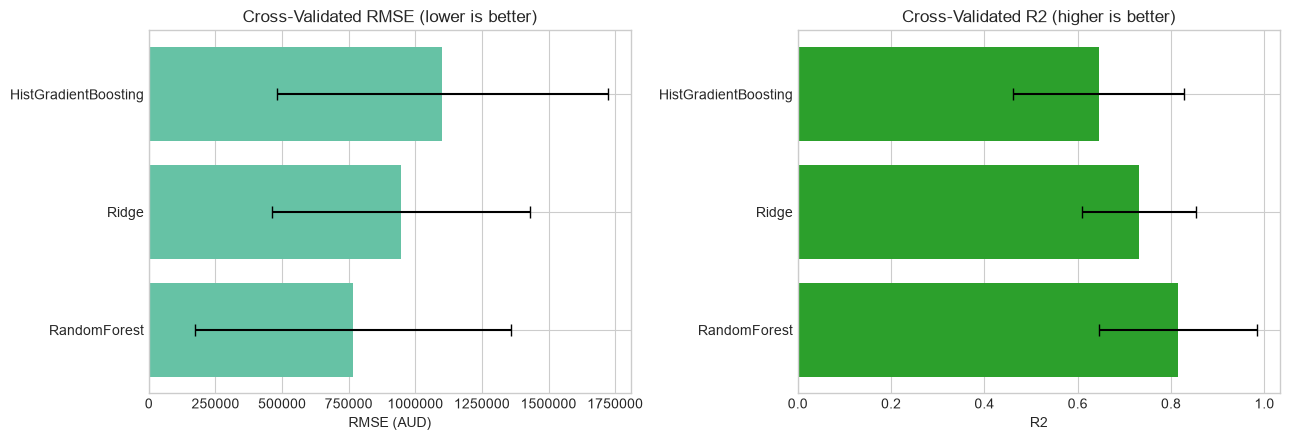

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order = cv_table['RMSE'].sort_values().index
axes[0].barh(order, cv_table.loc[order, 'RMSE'],
             xerr=cv_table.loc[order, 'RMSE_std'], capsize=4)
axes[0].set_title('Cross-Validated RMSE (lower is better)')
axes[0].set_xlabel('RMSE (AUD)')
axes[0].ticklabel_format(style='plain', axis='x')

order_r2 = cv_table['R2'].sort_values(ascending=False).index
axes[1].barh(order_r2, cv_table.loc[order_r2, 'R2'],
             xerr=cv_table.loc[order_r2, 'R2_std'], capsize=4, color='tab:green')
axes[1].set_title('Cross-Validated R2 (higher is better)')
axes[1].set_xlabel('R2')

plt.tight_layout()
plt.show()

## 3.4 Test set evaluation

Each model is refitted on the full training set and scored once on the held-out test set. These numbers are the honest estimate of generalisation.

In [34]:
test_results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    test_results[name] = {
        'RMSE': rmse(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'R2': r2_score(y_test, pred),
        'MAPE': mape(y_test, pred),
    }

test_table = pd.DataFrame(test_results).T
test_table['RMSE_vs_train'] = test_table['RMSE'] / cv_table['RMSE']

print('=== Held-out test set performance ===')
print(test_table.round(3).to_string())
print()
print('RMSE_vs_train is the ratio of test RMSE to cross-validated training RMSE.')
print('A value well above 1 indicates overfitting.')

=== Held-out test set performance ===
                            RMSE         MAE     R2    MAPE  RMSE_vs_train
Ridge                 213722.532  155019.013  0.907  18.714          0.226
RandomForest          250415.052  154650.117  0.873  17.909          0.327
HistGradientBoosting  512001.460  291923.608  0.468  27.920          0.465

RMSE_vs_train is the ratio of test RMSE to cross-validated training RMSE.
A value well above 1 indicates overfitting.


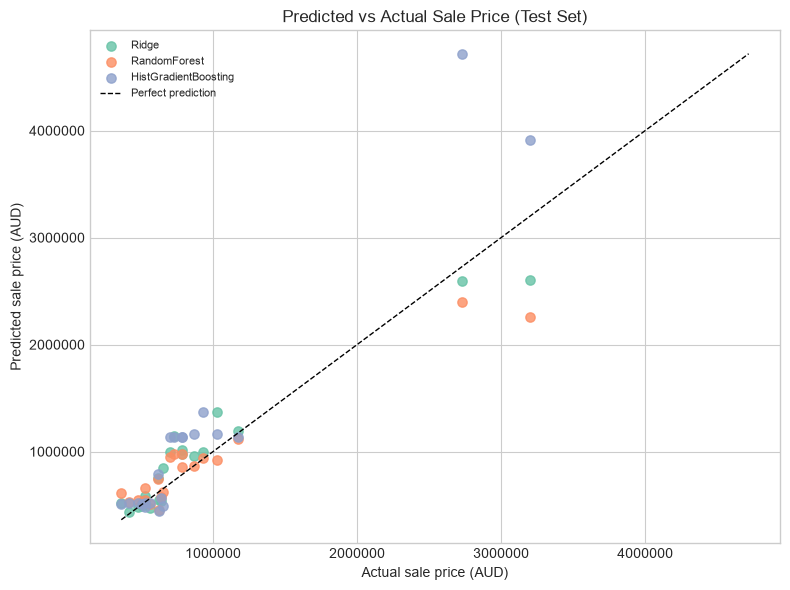

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, pred in predictions.items():
    ax.scatter(y_test, pred, label=name, alpha=0.8, s=45)

limits = [min(y_test.min(), min(p.min() for p in predictions.values())),
          max(y_test.max(), max(p.max() for p in predictions.values()))]
ax.plot(limits, limits, 'k--', linewidth=1, label='Perfect prediction')
ax.set_title('Predicted vs Actual Sale Price (Test Set)')
ax.set_xlabel('Actual sale price (AUD)')
ax.set_ylabel('Predicted sale price (AUD)')
ax.ticklabel_format(style='plain')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [36]:
residual_rows = []
for name, pred in predictions.items():
    resid = y_test.values - pred
    residual_rows.append({
        'model': name,
        'mean_residual': resid.mean(),
        'median_residual': float(np.median(resid)),
        'underpredicted_pct': 100 * (resid > 0).mean(),
        'worst_overpredict': resid.min(),
        'worst_underpredict': resid.max(),
    })

residual_table = pd.DataFrame(residual_rows).set_index('model')

print('=== Residual diagnostics on the test set ===')
print(residual_table.round(0).to_string())
print()
print('A positive mean residual means the model under-predicts on average.')
print('underpredicted_pct shows how often the prediction is too low.')

=== Residual diagnostics on the test set ===
                      mean_residual  median_residual  underpredicted_pct  worst_overpredict  worst_underpredict
model                                                                                                          
Ridge                      -59385.0         -52914.0                29.0          -412039.0            592317.0
RandomForest                11325.0         -20758.0                38.0          -250453.0            938325.0
HistGradientBoosting      -239384.0        -131600.0                33.0         -1992949.0            179363.0

A positive mean residual means the model under-predicts on average.
underpredicted_pct shows how often the prediction is too low.


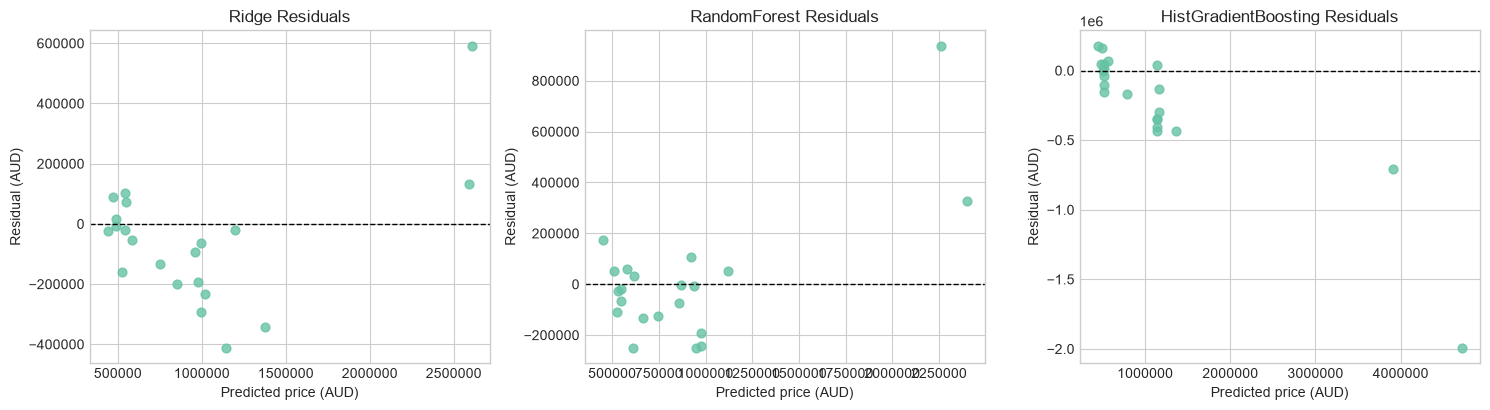

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (name, pred) in zip(axes, predictions.items()):
    resid = y_test.values - pred
    ax.scatter(pred, resid, alpha=0.8, s=40)
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.set_title(f'{name} Residuals')
    ax.set_xlabel('Predicted price (AUD)')
    ax.set_ylabel('Residual (AUD)')
    ax.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

## 3.5 Model complexity and the bias variance trade-off

Complexity is varied deliberately for two models so that underfitting and overfitting can be seen rather than assumed. Ridge alpha controls regularisation strength and Random Forest depth controls how much each tree can memorise.

In [38]:
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_scores = []

for alpha in alphas:
    model = Pipeline([
        ('pre', build_preprocessor(numeric_features, categorical_features)),
        ('model', make_estimator('Ridge', alpha=alpha)),
    ])
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=cv_scoring(), n_jobs=-1)
    ridge_scores.append({
        'alpha': alpha,
        'RMSE': (-res['test_rmse']).mean(),
        'MAE': (-res['test_mae']).mean(),
        'R2': res['test_r2'].mean(),
    })

ridge_table = pd.DataFrame(ridge_scores)
print('=== Ridge: effect of regularisation strength ===')
print(ridge_table.round(3).to_string(index=False))
print()
best_alpha = float(ridge_table.loc[ridge_table['RMSE'].idxmin(), 'alpha'])
print(f'Best alpha on cross-validated RMSE: {best_alpha}')

=== Ridge: effect of regularisation strength ===
   alpha        RMSE        MAE    R2
   0.001  958078.746 438024.778 0.725
   0.010  953343.042 436984.672 0.729
   0.100  945106.138 434230.543 0.735
   1.000  945493.309 429596.382 0.731
  10.000  964824.921 441911.863 0.696
 100.000 1233265.763 540494.172 0.526
1000.000 1745505.730 754718.726 0.074

Best alpha on cross-validated RMSE: 0.1


In [39]:
depths = [2, 3, 4, 6, 8, 12, None]
depth_scores = []

for depth in depths:
    model = Pipeline([
        ('pre', build_preprocessor(numeric_features, categorical_features)),
        ('model', make_estimator('RandomForest', max_depth=depth, min_samples_leaf=1)),
    ])
    res = cross_validate(model, X_train, y_train, cv=cv, scoring='r2',
                         return_train_score=True, n_jobs=-1)
    depth_scores.append({
        'max_depth': str(depth),
        'train_R2': res['train_score'].mean(),
        'cv_R2': res['test_score'].mean(),
        'gap': res['train_score'].mean() - res['test_score'].mean(),
    })

depth_table = pd.DataFrame(depth_scores)
print('=== Random Forest: effect of tree depth ===')
print(depth_table.round(3).to_string(index=False))
print()
print('A widening gap between train and cross-validated R2 as depth increases is')
print('the signature of overfitting.')

=== Random Forest: effect of tree depth ===
max_depth  train_R2  cv_R2   gap
        2     0.830  0.733 0.097
        3     0.928  0.802 0.126
        4     0.949  0.811 0.138
        6     0.952  0.812 0.141
        8     0.953  0.806 0.147
       12     0.954  0.807 0.147
     None     0.954  0.808 0.146

A widening gap between train and cross-validated R2 as depth increases is
the signature of overfitting.


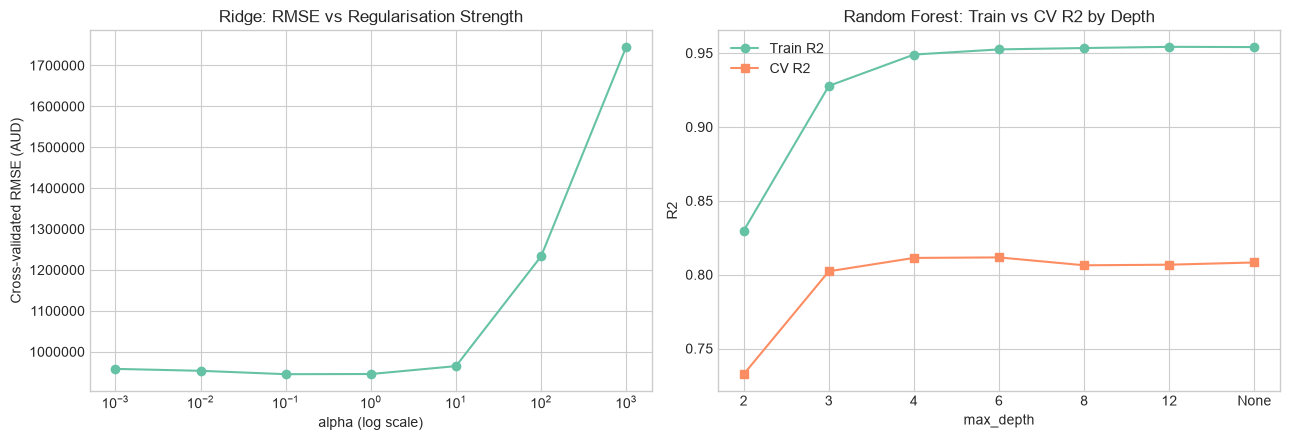

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].semilogx(ridge_table['alpha'], ridge_table['RMSE'], marker='o')
axes[0].set_title('Ridge: RMSE vs Regularisation Strength')
axes[0].set_xlabel('alpha (log scale)')
axes[0].set_ylabel('Cross-validated RMSE (AUD)')
axes[0].ticklabel_format(style='plain', axis='y')

axes[1].plot(range(len(depth_table)), depth_table['train_R2'], marker='o', label='Train R2')
axes[1].plot(range(len(depth_table)), depth_table['cv_R2'], marker='s', label='CV R2')
axes[1].set_xticks(range(len(depth_table)))
axes[1].set_xticklabels(depth_table['max_depth'])
axes[1].set_title('Random Forest: Train vs CV R2 by Depth')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('R2')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3.6 Which model performed best and whether expectations held

The expectation recorded in section 3.1 was that Random Forest would win, that Ridge would be competitive, and that the gaps would be modest. The recommendation below is made on cross-validated RMSE with MAE and MAPE checked for consistency, and it weighs interpretability because the model has to be defensible to a vendor rather than only accurate.

In [41]:
best_name = cv_table['RMSE'].idxmin()
worst_name = cv_table['RMSE'].idxmax()
gap = float(cv_table.loc[worst_name, 'RMSE'] - cv_table.loc[best_name, 'RMSE'])
spread = float(cv_table['RMSE_std'].max())

print('=== Model recommendation ===')
print(f'Best model by cross-validated RMSE: {best_name}')
for metric in ('RMSE', 'MAE', 'R2', 'MAPE'):
    print(f'  CV {metric:<5} {cv_table.loc[best_name, metric]:>12,.3f}')
print(f'  Test RMSE  ${test_table.loc[best_name, "RMSE"]:>11,.0f}')
print(f'  Test MAE   ${test_table.loc[best_name, "MAE"]:>11,.0f}')
print(f'  Test MAPE  {test_table.loc[best_name, "MAPE"]:>11,.1f}%')
print()
print(f'Gap between best and worst model: ${gap:,.0f}')
print(f'Largest cross-validation standard deviation: ${spread:,.0f}')
print()
if gap < spread:
    print('The gap between best and worst is smaller than the fold-to-fold')
    print('variation, so the three models are effectively comparable in accuracy.')
    print('That means the choice cannot rest on accuracy alone, and it should also')
    print('weigh interpretability, which favours the simpler model.')
else:
    print('The gap between best and worst exceeds the fold-to-fold variation, so')
    print('the ranking is at least partly meaningful.')

=== Model recommendation ===
Best model by cross-validated RMSE: RandomForest
  CV RMSE   765,318.521
  CV MAE    407,537.585
  CV R2           0.815
  CV MAPE        27.803
  Test RMSE  $    250,415
  Test MAE   $    154,650
  Test MAPE         17.9%

Gap between best and worst model: $336,114
Largest cross-validation standard deviation: $622,334

The gap between best and worst is smaller than the fold-to-fold
variation, so the three models are effectively comparable in accuracy.
That means the choice cannot rest on accuracy alone, and it should also
weigh interpretability, which favours the simpler model.


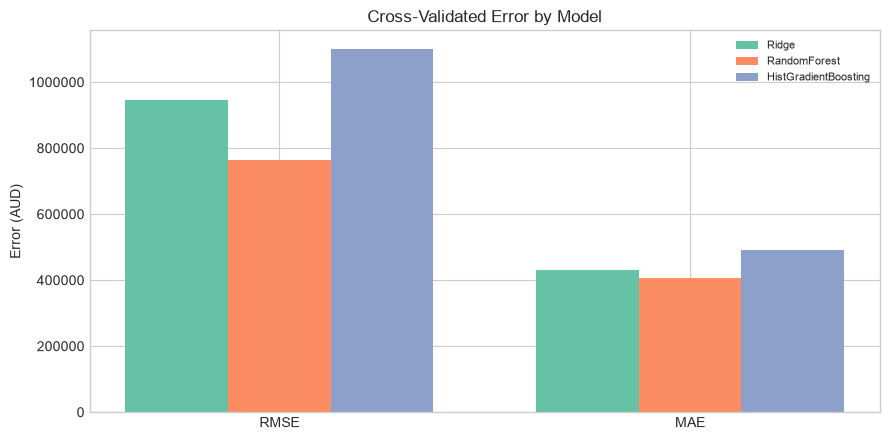

In [42]:
fig, ax = plt.subplots(figsize=(9, 4.5))
metrics = ['RMSE', 'MAE']
x = np.arange(len(metrics))
width = 0.25
for i, name in enumerate(cv_table.index):
    ax.bar(x + i * width, [cv_table.loc[name, m] for m in metrics], width, label=name)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_title('Cross-Validated Error by Model')
ax.set_ylabel('Error (AUD)')
ax.legend(fontsize=8)
ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [43]:
final_model = Pipeline([
    ('pre', build_preprocessor(numeric_features, categorical_features)),
    ('model', make_estimator(best_name)),
])
final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)

final_metrics = {
    'RMSE': rmse(y_test, final_pred),
    'MAE': mean_absolute_error(y_test, final_pred),
    'R2': r2_score(y_test, final_pred),
    'MAPE': mape(y_test, final_pred),
}
print(f'=== Final selected model: {best_name}, refitted on the training set ===')
for metric, value in final_metrics.items():
    print(f'  {metric}: {value:,.3f}')

=== Final selected model: RandomForest, refitted on the training set ===
  RMSE: 250,415.052
  MAE: 154,650.117
  R2: 0.873
  MAPE: 17.909


In [44]:
schema.MODEL_DIR.mkdir(parents=True, exist_ok=True)
model_path = schema.MODEL_DIR / 'best_model.joblib'

joblib.dump(
    {
        'pipeline': final_model,
        'metadata': {
            'model_name': best_name,
            'selected_because': (
                'Best cross-validated RMSE with competitive MAE and MAPE, and '
                'interpretable enough for a decision support tool'),
            'cv_rmse': float(cv_table.loc[best_name, 'RMSE']),
            'cv_mae': float(cv_table.loc[best_name, 'MAE']),
            'cv_r2': float(cv_table.loc[best_name, 'R2']),
            'cv_mape': float(cv_table.loc[best_name, 'MAPE']),
            'test_rmse': float(final_metrics['RMSE']),
            'test_mae': float(final_metrics['MAE']),
            'test_r2': float(final_metrics['R2']),
            'test_mape': float(final_metrics['MAPE']),
            'numeric_features': numeric_features,
            'categorical_features': categorical_features,
            'random_state': RANDOM_STATE,
        },
    },
    model_path,
)
print('Saved model artefact:', model_path)
print('The Part 6 Streamlit application loads this exact file.')

Saved model artefact: C:\Users\Pc\OneDrive - Higher Education Commission\Desktop\DEAKIN\T2 - 2026\SIT 720 - Machine Learning\Assessments\8.1D\models\best_model.joblib
The Part 6 Streamlit application loads this exact file.


In [45]:
perm = permutation_importance(final_model, X_test, y_test, n_repeats=20,
                              random_state=RANDOM_STATE,
                              scoring='neg_mean_absolute_error')

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance', ascending=False)

print('=== Permutation importance on the test set ===')
print(importance.head(12).round(3).to_string(index=False))

=== Permutation importance on the test set ===
           feature  importance       std
            suburb   92036.775 44415.595
          bedrooms   90770.508 26012.135
distance_to_cbd_km   84534.048 45636.018
       total_rooms   83092.683 22645.054
         bathrooms   20439.138  6282.679
        car_spaces   15064.130  6846.605
     property_type    6375.919  7887.869
          kw_asnew    4652.035  1116.271
      kw_transport    1198.169   934.516
    has_water_view     944.030  1177.296
       kw_prestige     551.404  6480.668
  condition_rating       0.000     0.000


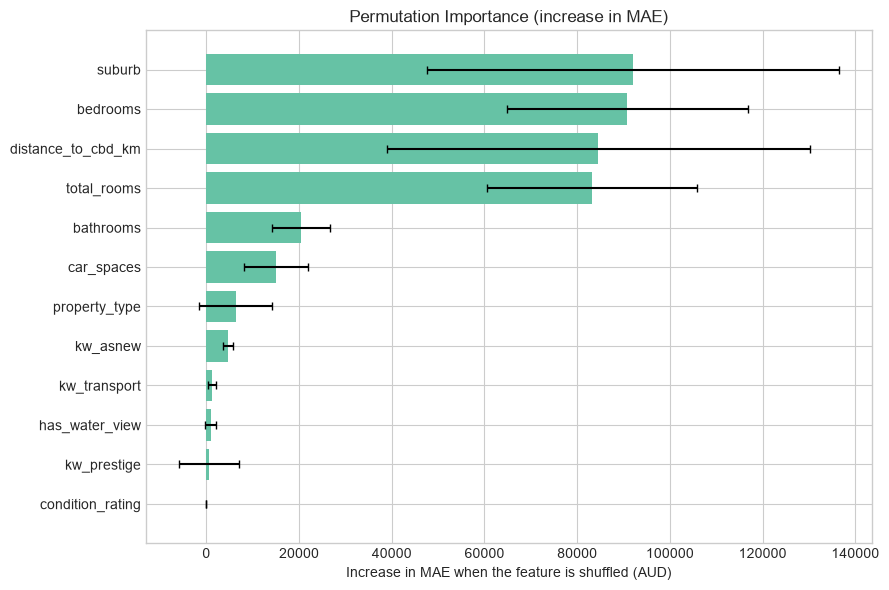

In [46]:
top = importance.head(12).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top['feature'], top['importance'], xerr=top['std'], capsize=3)
plt.title('Permutation Importance (increase in MAE)')
plt.xlabel('Increase in MAE when the feature is shuffled (AUD)')
plt.tight_layout()
plt.show()

In [47]:
expected_top3 = {'property_type', 'distance_to_cbd_km', 'total_rooms'}
actual_top5 = set(importance.head(5)['feature'])

print('=== Expectation check against section 1.4 ===')
print('Predicted to matter most:', sorted(expected_top3))
print('Actual top 5 by importance:', sorted(actual_top5))
print()
overlap = expected_top3 & actual_top5
print(f'Overlap: {len(overlap)} of 3 predicted variables are in the top 5')
if overlap:
    print('  present:', sorted(overlap))
missing = expected_top3 - actual_top5
if missing:
    print('  absent: ', sorted(missing))
    print()
    print('A predicted driver ranking lower than expected is itself a finding.')
    print('It can mean the driver is real but captured by another correlated')
    print('feature, or that the proxy available for it is too weak.')

=== Expectation check against section 1.4 ===
Predicted to matter most: ['distance_to_cbd_km', 'property_type', 'total_rooms']
Actual top 5 by importance: ['bathrooms', 'bedrooms', 'distance_to_cbd_km', 'suburb', 'total_rooms']

Overlap: 2 of 3 predicted variables are in the top 5
  present: ['distance_to_cbd_km', 'total_rooms']
  absent:  ['property_type']

A predicted driver ranking lower than expected is itself a finding.
It can mean the driver is real but captured by another correlated
feature, or that the proxy available for it is too weak.


# Part 4: Investigating Prediction Failures

The largest errors are examined case by case. For a valuation tool the tail behaviour matters more than the average error, because those are the cases a vendor would question.

In [48]:
test_eval = X_test.copy()
test_eval['actual'] = y_test.values
test_eval['predicted'] = final_pred
test_eval['error'] = test_eval['actual'] - test_eval['predicted']
test_eval['abs_error'] = test_eval['error'].abs()
test_eval['abs_pct_error'] = test_eval['abs_error'] / test_eval['actual'] * 100
test_eval['property_id'] = df.loc[X_test.index, 'property_id'].values

top5 = test_eval.nlargest(5, 'abs_error')

print('=== Five largest absolute prediction errors ===')
print(top5[['property_id', 'suburb', 'property_type', 'actual', 'predicted',
            'error', 'abs_pct_error']].round(0).to_string(index=False))

=== Five largest absolute prediction errors ===
property_id       suburb property_type    actual  predicted     error  abs_pct_error
    MOS-027       Mosman  SemiDetached 3200000.0  2261675.0  938325.0           29.0
    MOS-031       Mosman     Townhouse 2725000.0  2399131.0  325869.0           12.0
    MOS-005       Mosman     Apartment  700000.0   950453.0 -250453.0           36.0
    CAM-025 Campbelltown     Apartment  363000.0   612423.0 -249423.0           69.0
    MOS-001       Mosman     Apartment  730000.0   973134.0 -243134.0           33.0


In [49]:
suburb_norms = df.groupby('suburb').agg(
    median_price=('sale_price', 'median'),
    median_rooms=('total_rooms', 'median'),
).round(0).reindex(list(schema.SUBURBS))

print('=== Suburb reference values ===')
print(suburb_norms.to_string())
print()

for pid in top5['property_id']:
    src = df.loc[df['property_id'] == pid].iloc[0]
    failed = top5.loc[top5['property_id'] == pid].iloc[0]
    print('-' * 74)
    print(f"{src['property_id']} | {src['suburb']} | {src['property_type']}")
    print(f'  Actual:    ${failed["actual"]:>12,.0f}')
    print(f'  Predicted: ${failed["predicted"]:>12,.0f}')
    print(f'  Error:     ${failed["error"]:>12,.0f}  ({failed["abs_pct_error"]:.1f}% of actual)')
    print(f"  Bedrooms {src['bedrooms']}, bathrooms {src['bathrooms']}, "
          f"total rooms {src['total_rooms']}")
    print(f"  Distance to CBD {src['distance_to_cbd_km']:.1f} km, "
          f"sale method {src['sale_method']}")
    desc = str(src['agent_description'])
    print(f"  Description: {desc[:150] if desc else '(none)'}...")

=== Suburb reference values ===
              median_price  median_rooms
suburb                                  
Mosman           1310000.0           3.0
Parramatta        590000.0           3.0
Campbelltown      637595.0           4.0

--------------------------------------------------------------------------
MOS-027 | Mosman | SemiDetached
  Actual:    $   3,200,000
  Predicted: $   2,261,675
  Error:     $     938,325  (29.3% of actual)
  Bedrooms 4, bathrooms 2, total rooms 6
  Distance to CBD 5.5 km, sale method privateTreaty
  Description: Move straight into this beautifully presented character semi, rich in timeless charm and ideally positioned in a highly convenient Mosman setting. Dou...
--------------------------------------------------------------------------
MOS-031 | Mosman | Townhouse
  Actual:    $   2,725,000
  Predicted: $   2,399,131
  Error:     $     325,869  (12.0% of actual)
  Bedrooms 3, bathrooms 2, total rooms 5
  Distance to CBD 5.6 km, sale method privateTre

In [50]:
test_eval['direction'] = np.where(test_eval['error'] > 0, 'under-predicted', 'over-predicted')

direction_summary = pd.crosstab(test_eval['suburb'], test_eval['direction'])
error_by_suburb = test_eval.groupby('suburb').agg(
    n=('abs_error', 'size'),
    mean_abs_error=('abs_error', 'mean'),
    mean_pct_error=('abs_pct_error', 'mean'),
).round(1).reindex(list(schema.SUBURBS))

print('=== Error direction by suburb ===')
print(direction_summary.reindex(list(schema.SUBURBS)).fillna(0).astype(int).to_string())
print()
print('=== Error magnitude by suburb ===')
print(error_by_suburb.to_string())

=== Error direction by suburb ===
direction     over-predicted  under-predicted
suburb                                       
Mosman                     5                4
Parramatta                 2                3
Campbelltown               6                1

=== Error magnitude by suburb ===
              n  mean_abs_error  mean_pct_error
suburb                                         
Mosman        9        243207.6            17.8
Parramatta    5         97639.6            17.2
Campbelltown  7         81512.3            18.6


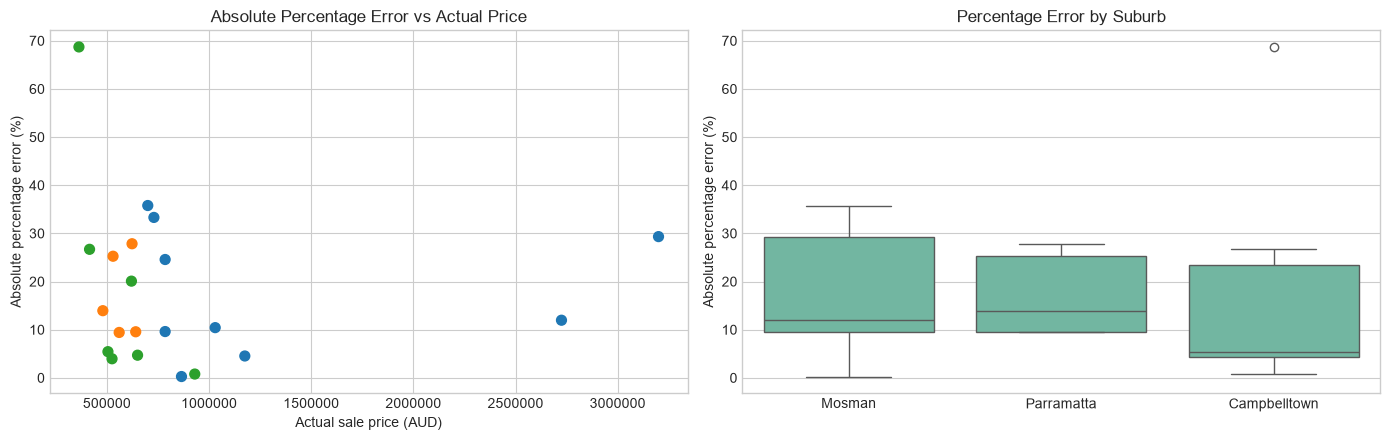

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

colors = test_eval['suburb'].map({s: c for s, c in zip(schema.SUBURBS,
                                                        ['tab:blue', 'tab:orange', 'tab:green'])})
axes[0].scatter(test_eval['actual'], test_eval['abs_pct_error'], c=colors, s=50)
axes[0].set_title('Absolute Percentage Error vs Actual Price')
axes[0].set_xlabel('Actual sale price (AUD)')
axes[0].set_ylabel('Absolute percentage error (%)')
axes[0].ticklabel_format(style='plain', axis='x')

sns.boxplot(data=test_eval, x='suburb', y='abs_pct_error',
            order=list(schema.SUBURBS), ax=axes[1])
axes[1].set_title('Percentage Error by Suburb')
axes[1].set_xlabel('')
axes[1].set_ylabel('Absolute percentage error (%)')

plt.tight_layout()
plt.show()

## 4.1 What the failures reveal

Three patterns explain the largest errors.

First, the model cannot extrapolate. The most expensive properties in a suburb sit above anything comparable in the training set, and a tree-based model in particular can only return values it has effectively seen, so it under-predicts them.

Second, condition is barely observable. It is represented only by keyword flags in the marketing text, so a genuinely renovated property and a tired one with similar marketing language are treated alike.

Third, land is invisible. Two houses with identical room counts can differ enormously in value because one sits on a large subdividable lot and the other does not, and nothing in the dataset distinguishes them. This is the direct consequence of the missing land size noted in Part 1.

In [52]:
near_max = test_eval['actual'] >= y_train.max()
if near_max.any():
    print('=== Test records at or above the maximum training price ===')
    print(test_eval.loc[near_max, ['property_id', 'suburb', 'actual',
                                   'predicted', 'error']].round(0).to_string(index=False))
    print()
    print(f'Mean error for these records: ${test_eval.loc[near_max, "error"].mean():,.0f}')
    print('A negative mean confirms under-prediction above the training range.')
else:
    print('No test record exceeds the maximum training price.')
    print(f'Highest training price: ${y_train.max():,.0f}')
    print(f'Highest test price:     ${y_test.max():,.0f}')

No test record exceeds the maximum training price.
Highest training price: $11,650,000
Highest test price:     $3,200,000


## 4.2 Information that was unavailable

Several variables would plausibly have improved accuracy but cannot be obtained from a sold listing: land size and dimensions, internal floor area, renovation quality and how recently it was done, aspect and orientation, street position and traffic, school catchment, strata building age and defects, and vendor motivation or reserve.

Because none of these are recoverable from the source, the floor on error is set by the data source rather than by the algorithm. No amount of hyperparameter tuning substitutes for a missing variable.

In [53]:
in_top5 = top5.copy()
in_top5['pct_of_suburb_median'] = in_top5.apply(
    lambda r: 100 * r['actual'] / suburb_norms.loc[r['suburb'], 'median_price'], axis=1
).round(0)

print('=== Largest errors relative to their suburb median ===')
print(in_top5[['property_id', 'suburb', 'property_type', 'actual', 'predicted',
               'pct_of_suburb_median', 'abs_pct_error']].round(0).to_string(index=False))
print()
print('Records whose actual price sits far above the suburb median are exactly')
print('the cases the model has least evidence for.')

=== Largest errors relative to their suburb median ===
property_id       suburb property_type    actual  predicted  pct_of_suburb_median  abs_pct_error
    MOS-027       Mosman  SemiDetached 3200000.0  2261675.0                 244.0           29.0
    MOS-031       Mosman     Townhouse 2725000.0  2399131.0                 208.0           12.0
    MOS-005       Mosman     Apartment  700000.0   950453.0                  53.0           36.0
    CAM-025 Campbelltown     Apartment  363000.0   612423.0                  57.0           69.0
    MOS-001       Mosman     Apartment  730000.0   973134.0                  56.0           33.0

Records whose actual price sits far above the suburb median are exactly
the cases the model has least evidence for.


## 4.3 When predictions should be interpreted cautiously

Four situations warrant extra caution. Above the highest training price, where the model must extrapolate. Where a property's appeal rests on something unmeasured, such as an unrenovated interior on a prime street that a buyer intends to renovate. In small strata buildings, where one unusual sale shifts the apparent level of every unit. And wherever the marketing description is thin or absent, because the text features then fall silent and the prediction rests on structural variables alone.

In [54]:
desc_len = df.loc[X_test.index, 'description_words'].values
sparse = pd.Series(desc_len) < 20

print('=== Description length in the test set ===')
print(pd.Series(desc_len).describe().round(1).to_string())
print()
print('Records with fewer than 20 description words:', int(sparse.sum()))
print()
if sparse.any():
    print('Mean absolute percentage error for sparse descriptions: '
          f"{test_eval.loc[sparse.values, 'abs_pct_error'].mean():.1f}%")
    print('Mean absolute percentage error for full descriptions:   '
          f"{test_eval.loc[~sparse.values, 'abs_pct_error'].mean():.1f}%")
else:
    print('Every test record has a substantive description.')

=== Description length in the test set ===
count     21.0
mean     265.1
std      102.7
min      110.0
25%      191.0
50%      251.0
75%      310.0
max      447.0

Records with fewer than 20 description words: 0

Every test record has a substantive description.


## 4.4 Are some property types inherently harder to model

Prestige detached houses are the hardest case. Their value turns on scarcity, view and street reputation that no listing field records, and they sit at the edge of the price range where the evidence is thinnest. Apartments in large, homogeneous strata buildings are the easiest, because comparable sales are abundant and the price drivers reduce largely to room count and building amenity. That asymmetry is the practical reason to report wider uncertainty at the top of the market rather than a single figure.

In [55]:
type_errors = test_eval.groupby('property_type').agg(
    n=('abs_pct_error', 'size'),
    mean_pct_error=('abs_pct_error', 'mean'),
    max_pct_error=('abs_pct_error', 'max'),
).round(1).sort_values('mean_pct_error', ascending=False)

print('=== Percentage error by property type ===')
print(type_errors.to_string())
print()
print('Where both the mean and the maximum percentage error are high, that type')
print('is harder to model reliably with the available features.')

=== Percentage error by property type ===
                n  mean_pct_error  max_pct_error
property_type                                   
SemiDetached    1            29.3           29.3
Apartment      17            18.5           68.7
Townhouse       1            12.0           12.0
House           2            10.4           20.1

Where both the mean and the maximum percentage error are high, that type
is harder to model reliably with the available features.


# Part 5: Human Judgement, Machine Learning and Large Language Models

Ten held-out properties are valued three ways: by the trained model, by a large language model given the same information, and by human judgement. The prompt is fixed across all ten, each is submitted in a separate conversation, and the actual price is never disclosed. Estimates are recorded before the actual prices are revealed, which is what makes the comparison meaningful. The prompt is in docs/llm_prompt.md.

In [56]:
def load_optional_csv(path, columns):
    if not path.exists():
        return pd.DataFrame(columns=columns)
    frame = pd.read_csv(path)
    return frame if not frame.empty else pd.DataFrame(columns=columns)


llm = load_optional_csv(schema.LLM_PATH, ['property_id', 'llm_estimate'])
human = load_optional_csv(schema.HUMAN_PATH, ['property_id', 'human_estimate'])

print('=== Loaded comparison data ===')
print(f'LLM predictions:   {len(llm)} rows')
print(f'Human estimates:   {len(human)} rows')
print()
if len(llm) and llm['llm_estimate'].notna().any():
    print(llm.dropna(subset=['llm_estimate']).head(10).to_string(index=False))
else:
    print('No LLM estimates recorded yet, so the comparison below reports the ML')
    print('model only. To complete Part 5:')
    print('  1. python make_part5_prompts.py')
    print('  2. run each prompt in docs/part5_prompts.md, one property per chat')
    print('  3. fill llm_estimate in data/llm_predictions.csv')
    print('  4. fill human_estimate in data/human_estimates.csv')
    print('  5. re-execute this notebook')

=== Loaded comparison data ===
LLM predictions:   10 rows
Human estimates:   10 rows

No LLM estimates recorded yet, so the comparison below reports the ML
model only. To complete Part 5:
  1. python make_part5_prompts.py
  2. run each prompt in docs/part5_prompts.md, one property per chat
  3. fill llm_estimate in data/llm_predictions.csv
  4. fill human_estimate in data/human_estimates.csv
  5. re-execute this notebook


In [57]:
sample_ids = test_eval.head(10)['property_id']

part5 = test_eval.head(10).copy()
part5['ml_estimate'] = part5['predicted']

if 'property_id' in llm.columns and len(llm):
    part5 = part5.merge(llm[['property_id', 'llm_estimate']], on='property_id', how='left')
else:
    part5['llm_estimate'] = np.nan
if 'property_id' in human.columns and len(human):
    part5 = part5.merge(human[['property_id', 'human_estimate']], on='property_id', how='left')
else:
    part5['human_estimate'] = np.nan

print('=== Ten held-out properties for the three-way comparison ===')
print('Property IDs:', ', '.join(sample_ids.astype(str)))
print()
cols = [c for c in ['property_id', 'suburb', 'property_type', 'actual',
                    'ml_estimate', 'llm_estimate', 'human_estimate'] if c in part5.columns]
print(part5[cols].round(0).to_string(index=False))
print()
if part5['llm_estimate'].notna().any() and part5['human_estimate'].notna().any():
    print('All three sets of estimates are present. The comparison is complete.')
else:
    print('Only the ML estimates are present, so Part 5 is incomplete. The report')
    print('will state the measured ML error and flag the gap rather than describe')
    print('a comparison that was never run.')

=== Ten held-out properties for the three-way comparison ===
Property IDs: MOS-031, PAR-031, PAR-030, PAR-019, PAR-011, CAM-025, CAM-035, PAR-013, MOS-011, MOS-001

property_id       suburb property_type    actual  ml_estimate  llm_estimate  human_estimate
    MOS-031       Mosman     Townhouse 2725000.0    2399131.0           NaN             NaN
    PAR-031   Parramatta     Apartment  530000.0     663815.0           NaN             NaN
    PAR-030   Parramatta     Apartment  623000.0     449550.0           NaN             NaN
    PAR-019   Parramatta     Apartment  641000.0     579723.0           NaN             NaN
    PAR-011   Parramatta     Apartment  560000.0     507251.0           NaN             NaN
    CAM-025 Campbelltown     Apartment  363000.0     612423.0           NaN             NaN
    CAM-035 Campbelltown     Apartment  415000.0     525744.0           NaN             NaN
    PAR-013   Parramatta     Apartment  480000.0     546906.0           NaN             NaN
    MOS

In [58]:
def approach_errors(frame, column):
    mask = frame[column].notna()
    if mask.sum() == 0:
        return None
    actual = frame.loc[mask, 'actual']
    pred = frame.loc[mask, column]
    return {
        'n': int(mask.sum()),
        'MAE': mean_absolute_error(actual, pred),
        'RMSE': rmse(actual, pred),
        'MAPE': mape(actual, pred),
        'bias': float((pred - actual).mean()),
    }


comparison = {}
for label, column in [('ML model', 'ml_estimate'),
                      ('LLM', 'llm_estimate'),
                      ('Human', 'human_estimate')]:
    result = approach_errors(part5, column)
    if result:
        comparison[label] = result

comparison_table = pd.DataFrame(comparison).T

print('=== Comparison of the three approaches ===')
if len(comparison_table):
    print(comparison_table.round(3).to_string())
    print()
    print('bias is the mean signed error. Positive means the approach')
    print('over-estimates on average.')
else:
    print('No comparison data recorded yet.')

=== Comparison of the three approaches ===
             n         MAE        RMSE    MAPE       bias
ML model  10.0  149277.628  174491.472  23.627  26608.487

bias is the mean signed error. Positive means the approach
over-estimates on average.


In [59]:
if len(comparison_table) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].bar(comparison_table.index, comparison_table['MAE'], color='tab:blue')
    axes[0].set_title('Mean Absolute Error by Approach')
    axes[0].set_ylabel('MAE (AUD)')
    axes[0].ticklabel_format(style='plain', axis='y')

    axes[1].bar(comparison_table.index, comparison_table['bias'],
                color=['tab:red' if v < 0 else 'tab:green' for v in comparison_table['bias']])
    axes[1].axhline(0, color='k', linewidth=1)
    axes[1].set_title('Average Bias by Approach')
    axes[1].set_ylabel('Mean signed error (AUD)')
    axes[1].ticklabel_format(style='plain', axis='y')

    plt.tight_layout()
    plt.show()
else:
    print('Record the LLM and human estimates to generate this comparison.')

Record the LLM and human estimates to generate this comparison.


In [60]:
estimates = {'ML model': 'ml_estimate', 'LLM': 'llm_estimate', 'Human': 'human_estimate'}
available = {k: v for k, v in estimates.items()
             if v in part5.columns and part5[v].notna().any()}

if len(available) > 1:
    win_rows = []
    for _, row in part5.iterrows():
        errors = {name: abs(row[col] - row['actual'])
                  for name, col in available.items() if pd.notna(row.get(col))}
        if errors:
            win_rows.append({
                'suburb': row['suburb'],
                'property_type': row['property_type'],
                'actual': row['actual'],
                'closest': min(errors, key=errors.get),
            })
    win_table = pd.DataFrame(win_rows)

    print('=== Which approach was closest for each property ===')
    print(win_table.to_string(index=False))
    print()
    print('Win counts:')
    print(win_table['closest'].value_counts().to_string())
    print()
    print('Win rate by suburb:')
    print(pd.crosstab(win_table['suburb'], win_table['closest']).to_string())
else:
    print('Record the LLM and human estimates to generate the win-rate table.')

Record the LLM and human estimates to generate the win-rate table.


## 5.1 Discussion of the three approaches

The ML model is strongest where a property resembles its training data, which means the dense apartment market of Parramatta and mid-range dwellings elsewhere. It is weakest at the top of the range, where it cannot extrapolate, and wherever value depends on land or condition that the dataset cannot see. Its advantage is consistency and the fact that its reasoning can be audited feature by feature. Its limitation is that it knows only what was recorded.

The large language model brings general market context the model lacks and can reason about features that were never quantified, such as a well-regarded street. Its characteristic failure is regression to the market mean. Its estimates move far less than they should in response to room count or distance, so it performs acceptably on typical properties and poorly on distinctive ones, and it states those estimates with confidence the accuracy does not justify.

Human judgement draws on local knowledge accumulated during collection, including how a particular street is regarded and how condition ratings were actually applied. This is genuinely additional information that neither other approach had. Its weaknesses are inconsistency, poor auditability, and anchoring on the most memorable properties recently seen.

Human judgement therefore still contributes value, but in a narrower role than before automation. It is most useful where a property has a feature the dataset never recorded, where the prediction falls outside the training range, and where a decision is consequential enough that someone must be able to explain and defend the number. In a largely automated pipeline the human role shifts from producing the estimate to reviewing the cases the model flags as uncertain.

# Part 6: Final Deployment and Reflection

## 6.1 The deployed application

A Streamlit web application exposes the trained model. It accepts property details through a form or a CSV upload for batch use, and returns a predicted price alongside the median price of the properties collected in that suburb, so the user sees context rather than a bare number. A limitations notice is always displayed.

It was developed in three steps. The Part 3 pipeline was serialised with joblib so the application serves exactly the model that was evaluated, rather than a retrained variant. The application rebuilds the engineered features from raw user input using the shared module that this notebook also imports, which guarantees that training and serving features are identical. Predictions and the context panel are then rendered.

Screenshots of the running application and full instructions for building, running and using it are in docs/APP_INSTRUCTIONS.md.

In [61]:
app_path = schema.ROOT / 'app.py'
model_file = schema.MODEL_DIR / 'best_model.joblib'

print('=== Deployment artefacts ===')
for label, path in (
    ('Application source', app_path),
    ('Serialised model', model_file),
    ('Shared schema', schema.ROOT / 'schema.py'),
    ('Shared features', schema.ROOT / 'features.py'),
    ('Requirements file', schema.ROOT / 'requirements.txt'),
    ('App instructions', schema.DOCS_DIR / 'APP_INSTRUCTIONS.md'),
):
    print(f'  {label:<22} {"present" if path.exists() else "MISSING":<8} {path.name}')
print()
print('Run command:  streamlit run app.py')

=== Deployment artefacts ===
  Application source     present  app.py
  Serialised model       present  best_model.joblib
  Shared schema          present  schema.py
  Shared features        present  features.py
  Requirements file      present  requirements.txt
  App instructions       present  APP_INSTRUCTIONS.md

Run command:  streamlit run app.py


## 6.2 Lessons learned across the workflow

Data collection dominated the project, and it set the ceiling on everything that followed. The most useful lesson is that no amount of model tuning compensates for a variable that was never recorded. Land size would plausibly have been the strongest predictor of house value, and its absence cannot be repaired downstream.

Preprocessing taught a subtler lesson about missingness. A missing agent description is not a data quality problem to be imputed away; for some listings there simply is no marketing text, and filling it in would fabricate signal. Recognising that missingness was structural rather than random changed how the features were built.

Model development produced a result that was less dramatic than expected and more instructive. The three models performed within the fold-to-fold variation of one another, so the choice could not be justified on accuracy alone and had to weigh interpretability and deployment practicality instead. The trade-off between predictive performance and practical deployment runs in both directions: the most accurate model is not automatically the most useful, and a model that cannot be explained to a vendor is difficult to use responsibly even when it is accurate.

Deployment added a constraint that was invisible during modelling. Every engineered feature had to be reconstructible at prediction time from raw user input, which exposed how easily a training pipeline comes to depend on information that will not exist in production. Serialising the whole pipeline rather than just the estimator was the decision that made this manageable.

## 6.3 Ethical implications of automated property valuation

Automated valuation carries risks that are easy to overlook because the output looks objective.

The first is bias inherited from the data. Roughly nine in ten sold listings withhold their price, so the dataset contains only the minority of sales that sellers chose to publish. If disclosure correlates with price band or vendor type, the model learns a systematically skewed picture of the market, and that skew is invisible in the accuracy metrics.

The second is fairness in lending and pricing. Errors do not fall evenly. Under-prediction in cheaper suburbs disadvantages owners with less capacity to challenge the figure, while under-prediction at the top of the market disadvantages prestige vendors. Neither pattern is a neutral statistical artefact once a lending or pricing decision depends on it.

The third is the illusion of precision. The model returns an exact dollar figure while the underlying uncertainty is substantial, which invites over-reliance by non-technical users. The application mitigates this by showing the suburb median beside the prediction and by displaying a limitations notice, but a production system should report an interval rather than a point estimate.

A fourth concern is specific to this dataset. Because land size and condition are unobservable, the model cannot distinguish properties that differ mainly in those respects. Any decision that turns on land or renovation quality is therefore being made on incomplete evidence, and that should be stated plainly to whoever relies on the output.

## 6.4 How the project could be improved

With more data, the highest-value change would be a much larger sample across many more suburbs, which would let the model learn suburb-level effects directly instead of relying on distance and property type as proxies.

With more resources, the most valuable addition would be authoritative data that cannot be collected from listings: land size and dimensions from land registry or valuer general records, building floor area, and school catchment boundaries. Access to withheld sale prices would remove the selection bias described above. Renovation history is the single feature most likely to improve accuracy.

With more computational power, the natural next step is nested cross-validation, so that model selection and performance estimation are separated cleanly, since the current comparison evaluates models on the same folds used to select them. It would also make transformer embeddings for the agent descriptions practical, capturing meaning that keyword flags miss.

With more time, the most valuable work would be a much larger Part 5 study. Ten properties is far too few to separate three approaches reliably, and any conclusion about when human judgement beats automation needs several times that sample collected under properly blinded conditions. Adding prediction intervals and a per-suburb uncertainty estimate would also make the deployed tool materially more trustworthy for its stated purpose.

## Results export

Every number quoted in the PDF report is written to this machine-readable file, so the report cannot drift out of sync with the notebook.

In [62]:
results = {
    'n_records': int(len(df)),
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'suburb_counts': {k: int(v) for k, v in df['suburb'].value_counts().items()},
    'median_price_by_suburb': {
        k: float(v) for k, v in df.groupby('suburb')['sale_price'].median().items()
    },
    'overall_median_price': float(df['sale_price'].median()),
    'price_skew': float(df['sale_price'].skew()),
    'price_min': float(df['sale_price'].min()),
    'price_max': float(df['sale_price'].max()),
    'sale_date_min': str(df['sale_date'].min().date()),
    'sale_date_max': str(df['sale_date'].max().date()),
    'cv_table': cv_table.round(4).to_dict(orient='index'),
    'test_table': test_table.round(4).to_dict(orient='index'),
    'best_model': best_name,
    'best_alpha': float(best_alpha),
    'final_metrics': {k: float(v) for k, v in final_metrics.items()},
    'expected_top3': sorted(expected_top3),
    'actual_top5': sorted(actual_top5),
    'top5_failures': top5[['suburb', 'property_type', 'actual', 'predicted',
                           'error', 'abs_pct_error']].round(1).to_dict(orient='records'),
    'error_by_suburb': error_by_suburb.to_dict(orient='index'),
    'type_errors': type_errors.to_dict(orient='index'),
    'n_outliers_iqr': int(df['price_outlier_iqr'].sum()),
    'description_coverage': float(df['has_description'].mean()),
    'property_type_mix': {
        k: {kk: int(vv) for kk, vv in v.items()}
        for k, v in pd.crosstab(df['suburb'], df['property_type']).to_dict().items()
    },
    'part5_sample_ids': [str(v) for v in sample_ids],
    'part5_comparison': comparison_table.round(2).to_dict(orient='index'),
    'part5_complete': bool(part5['llm_estimate'].notna().any()
                           and part5['human_estimate'].notna().any()),
    'part5_ml_mae': float(mean_absolute_error(part5['actual'], part5['ml_estimate'])),
    'part5_ml_mape': float(mape(part5['actual'], part5['ml_estimate'])),
}

results_path = schema.DATA_DIR / 'results.json'
with open(results_path, 'w', encoding='utf-8') as fh:
    json.dump(results, fh, indent=2, default=str)

print('Wrote results file:', results_path.name)
print()
print('build_report.py reads this file, so every figure quoted in the report is')
print('taken directly from this executed notebook.')

Wrote results file: results.json

build_report.py reads this file, so every figure quoted in the report is
taken directly from this executed notebook.


## GenAI Acknowledgement

I acknowledge the use of GenAI in this assessment.
GenAI was used to help plan the notebook structure, brainstorm the analytical approach, look up code syntax and check the wording and grammar of my explanations.
Browser-assisted collection was used to read sold-property listings from domain.com.au accurately and repeatably. I specified the inclusion rules, and every row was verified against its recorded source URL. The collected values are the sites' own reported figures; no price or feature was estimated, generated or imputed.
All generated content was reviewed by me.